# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. These models allow us to model relationships where the outcome is not continuous, such as binary or categorical outcomes. Activation functions transform a linear combination of predictors into a nonlinear output. This is an advantage over ordinary linear models, which can produce unrealistic predictions and may not fit classification problems well.
2. Binary and categorical cross entropy are effective because they measure how far predictions are from the true outcomes. They penalize confident but incorrect predictions much more heavily than small errors, which helps the model learn meaningful probabilities.
3. Kind of true. Logistic regression is linear in the latent variable or log-odds. However, the logistic activation function transforms that linear relationship into a nonlinear probability.
4. False. Logistic regression is widely used for classification. It estimates probabilities that an observation belongs to a class, and those probabilities can be converted into classifications.
5. No, in logistic regression, coefficients represent the change in log-odds, not the direct change in predicted probability. The effect of a one-unit increase in a feature on probability depends on the starting probability level.
6. False. Logistic regression is only nonlinear because of the activation function and is still linear in the predictors unless features are engineered.
7. False. Logistic regression is better when the outcome is categorical or binary, but OLS is still appropriate for continuous outcomes.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [1]:
#Q1
import pandas as pd

df = pd.read_csv("data.csv", sep=";")

df = df[
    ['Debtor',
     'Tuition fees up to date',
     'Scholarship holder',
     'Age at enrollment',
     'Curricular units 1st sem (approved)',
     'Target']
]

print(df.isnull().sum())

df = df.dropna()

df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print(df[['Target','dropout']].head())
print(df['dropout'].value_counts())

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64
     Target  dropout
0   Dropout        1
1  Graduate        0
2   Dropout        1
3  Graduate        0
4  Graduate        0
dropout
0    3003
1    1421
Name: count, dtype: int64


In [2]:
#Q2
from sklearn.linear_model import LogisticRegression
import pandas as pd

X = df[['Debtor',
        'Tuition fees up to date',
        'Scholarship holder',
        'Age at enrollment']]

y = df['dropout']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

results = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

print(results)

print("Intercept:", model.intercept_[0])

                  Variable  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925
Intercept: 0.4856926578796168


The logistic regression results suggest that being a debtor and enrolling at an older age increase dropout probability, as both have positive coefficients. In contrast, being up to date on tuition and being a scholarship holder reduce dropout risk, as shown by their negative coefficients. The large negative coefficient on tuition fees up to date suggests it substantially lowers the likelihood of dropout. Overall, the results indicate financial stability is associated with lower dropout risk.


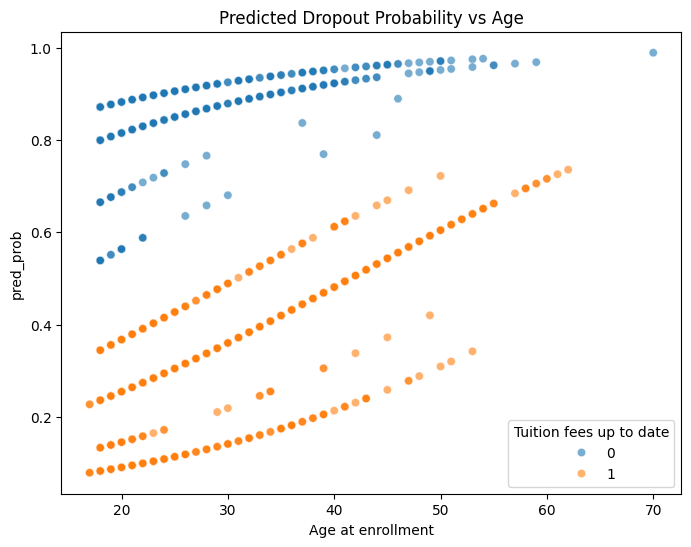

Average dropout probability if tuition up to date: 0.2626178914286205
Average dropout probability if tuition NOT up to date: 0.7787998656118034
Average change in dropout probability: -0.5161819741831828


In [3]:
#Q3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df['pred_prob'] = model.predict_proba(X)[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Age at enrollment',
    y='pred_prob',
    hue='Tuition fees up to date',
    alpha=0.6
)

plt.title('Predicted Dropout Probability vs Age')
plt.show()

X_tuition1 = X.copy()
X_tuition1['Tuition fees up to date'] = 1

X_tuition0 = X.copy()
X_tuition0['Tuition fees up to date'] = 0

prob1 = model.predict_proba(X_tuition1)[:,1]
prob0 = model.predict_proba(X_tuition0)[:,1]

print("Average dropout probability if tuition up to date:", np.mean(prob1))
print("Average dropout probability if tuition NOT up to date:", np.mean(prob0))
print("Average change in dropout probability:", np.mean(prob1 - prob0))

Ages 20-30 reduce dropout probability the most for individuals that are up to date on tuition. Being up to date on tuition dratsically reduces the dropout probability, atleast by half or so.

In [4]:
#Q4
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

Confusion Matrix:
[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


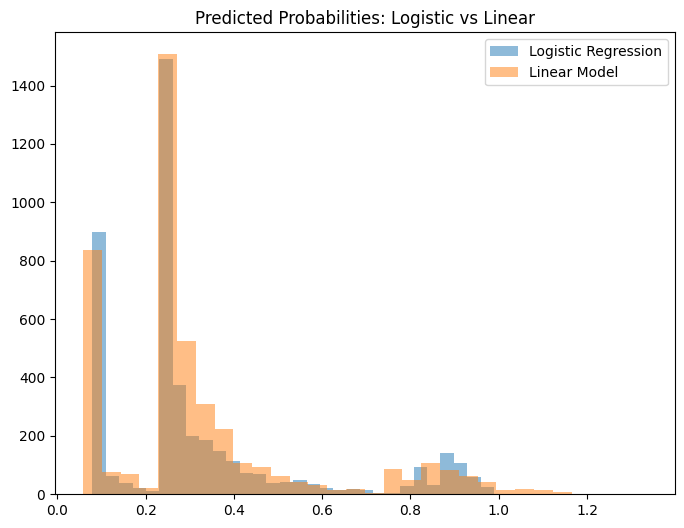

In [5]:
#Q5
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lin_model = LinearRegression()
lin_model.fit(X, y)

df['logit_prob'] = model.predict_proba(X)[:,1]
df['linear_prob'] = lin_model.predict(X)

plt.figure(figsize=(8,6))

plt.hist(df['logit_prob'], bins=30, alpha=0.5, label='Logistic Regression')
plt.hist(df['linear_prob'], bins=30, alpha=0.5, label='Linear Model')

plt.legend()
plt.title('Predicted Probabilities: Logistic vs Linear')
plt.show()

According to the histogram, both models show very similar performance. Overall, the linear model appears to have slightly higher predicted probabilites.

Q6. Based on the model, students most at risk of dropping out are one's whose tuition dues are NOT up to date and are ages 40+. Tuition assistance or work study programs could be helpful interventions to keep these individuals enrolled.

In [6]:
#Q7
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd

X_multi = df[
    ['Debtor',
     'Tuition fees up to date',
     'Curricular units 1st sem (approved)']
]

y_multi = df['Target']

multi_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=2000
)

multi_model.fit(X_multi, y_multi)

y_pred_multi = multi_model.predict(X_multi)

cm = confusion_matrix(y_multi, y_pred_multi)
print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy_score(y_multi, y_pred_multi))

print("\nClasses predicted by .predict:")
print(pd.Series(y_pred_multi).value_counts())

probs = pd.DataFrame(
    multi_model.predict_proba(X_multi),
    columns=multi_model.classes_
)

print("\nFirst 10 predicted probabilities:")
print(probs.head(10))

print("\nClasses included in predict_proba:")
print(probs.columns.tolist())

Confusion Matrix:
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
Accuracy: 0.7045660036166366

Classes predicted by .predict:
Graduate    2944
Dropout     1480
Name: count, dtype: int64

First 10 predicted probabilities:
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104
5  0.308421  0.323433  0.368146
6  0.071938  0.140644  0.787418
7  0.952988  0.041199  0.005813
8  0.117808  0.176983  0.705209
9  0.838886  0.122977  0.038136

Classes included in predict_proba:
['Dropout', 'Enrolled', 'Graduate']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The multinomial logistic regression achieved an accuracy of about 70.5%, suggesting moderate predictive performance. The confusion matrix shows the model performs reasonably well for Graduate and Dropout, but very poorly for Enrolled, as it never correctly classifies any observations into that category. This is confirmed by the hard classifications from .predict, which only predict Dropout and Graduate, meaning the model does not predict every class. However, the .predict_proba results assign probabilities to all three classes—Dropout, Enrolled, and Graduate—for every observation, including nonzero probabilities for Enrolled even though it is never selected as the final predicted class. This suggests hard classification misses one class entirely, while the probability predictions account for every class and provide a fuller picture of uncertainty.



**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [7]:
#Q1
import pandas as pd

df = pd.read_csv("cirrhosis.csv")

df = df[
    ['Bilirubin',
     'Edema',
     'Drug',
     'Stage',
     'Status']
]

# Check missing values
print(df.isnull().sum())

# Drop missing observations
df = df.dropna()

# Create binary target:
# 1 = Survived (C or CL)
# 0 = Dead (D)
df['survival'] = df['Status'].isin(['C','CL']).astype(int)

# Quick check
print(df[['Status','survival']].head())

# Check class counts
print(df['survival'].value_counts())

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64
  Status  survival
0      D         0
1      C         1
2      D         0
3      D         0
4     CL         1
survival
1    187
0    125
Name: count, dtype: int64


In [8]:
#Q2
from sklearn.linear_model import LogisticRegression
import pandas as pd

X = pd.get_dummies(
    df[['Edema','Drug','Bilirubin']],
    drop_first=True
)

y = df['survival']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

results = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})

print(results)
print("Intercept:", model.intercept_[0])

       Variable  Coefficient
0     Bilirubin    -0.351424
1       Edema_S    -0.450677
2       Edema_Y    -1.611049
3  Drug_Placebo     0.231225
Intercept: 1.3798277993022918


The logistic regression results suggest that **higher bilirubin is associated with lower survival probability**, as shown by its negative coefficient. Both forms of edema also reduce survival probability, with severe edema (**Edema_Y**) having a much stronger negative effect than mild edema (**Edema_S**). The positive coefficient on **Drug_Placebo** suggests patients in the placebo group have slightly higher survival probability, implying the drug does not appear to improve survival in this model. Overall, worse disease indicators—especially high bilirubin and severe edema—are associated with lower likelihood of survival.


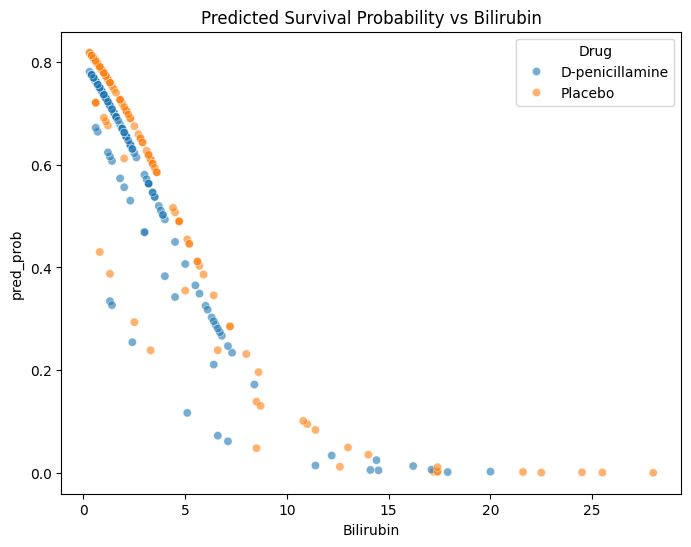

Average survival probability on drug: 0.5788738261212892
Average survival probability on placebo: 0.6213004655529292
Average change in survival probability: -0.042426639431640066


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df['pred_prob'] = model.predict_proba(X)[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Bilirubin',
    y='pred_prob',
    hue='Drug',
    alpha=0.6
)

plt.title('Predicted Survival Probability vs Bilirubin')
plt.show()

X_drug = X.copy()
X_drug['Drug_Placebo'] = 0

X_placebo = X.copy()
X_placebo['Drug_Placebo'] = 1

prob_drug = model.predict_proba(X_drug)[:,1]
prob_placebo = model.predict_proba(X_placebo)[:,1]

print("Average survival probability on drug:", np.mean(prob_drug))
print("Average survival probability on placebo:", np.mean(prob_placebo))
print("Average change in survival probability:", np.mean(prob_drug - prob_placebo))

It looks like values from 0-5 of Bilirubin have the highest correlated surival rate among patients. Patients on the drug have an avergae predicted survival probability of about 58%.

In [10]:
#Q4
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

Confusion Matrix:
[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


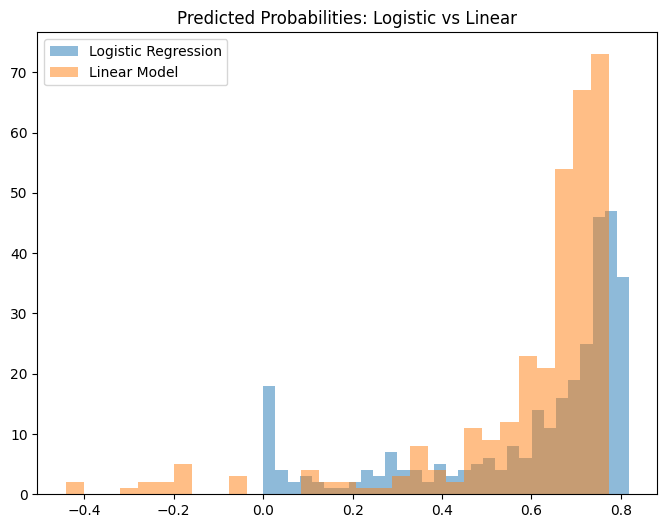

Linear model minimum: -0.4417396683935991
Linear model maximum: 0.7738680250928711


In [11]:
#Q5
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

lin_model = LinearRegression()
lin_model.fit(X, y)

df['logit_prob'] = model.predict_proba(X)[:,1]
df['linear_prob'] = lin_model.predict(X)

plt.figure(figsize=(8,6))

plt.hist(df['logit_prob'], bins=30, alpha=0.5, label='Logistic Regression')
plt.hist(df['linear_prob'], bins=30, alpha=0.5, label='Linear Model')

plt.legend()
plt.title('Predicted Probabilities: Logistic vs Linear')
plt.show()

print("Linear model minimum:", df['linear_prob'].min())
print("Linear model maximum:", df['linear_prob'].max())

The linear model appears to have overalln higher predicted probabilities than the logistic regression model. Both are concentrated in the 0.6-0.8 range.

In [12]:
#Q6
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd

X_stage = pd.get_dummies(
    df[['Edema','Bilirubin']],
    drop_first=True
)

y_stage = df['Stage']

stage_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=2000
)

stage_model.fit(X_stage, y_stage)

y_pred_stage = stage_model.predict(X_stage)

cm = confusion_matrix(y_stage, y_pred_stage)
print("Confusion Matrix:")
print(cm)

print("Accuracy:", accuracy_score(y_stage, y_pred_stage))

print("\nClasses predicted by .predict:")
print(pd.Series(y_pred_stage).value_counts())

probs = pd.DataFrame(
    stage_model.predict_proba(X_stage),
    columns=stage_model.classes_
)

print("\nFirst 10 predicted probabilities:")
print(probs.head(10))

print("\nClasses included in predict_proba:")
print(probs.columns.tolist())

Confusion Matrix:
[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
Accuracy: 0.4326923076923077

Classes predicted by .predict:
3.0    263
4.0     49
Name: count, dtype: int64

First 10 predicted probabilities:
        1.0       2.0       3.0       4.0
0  0.000013  0.032535  0.143611  0.823841
1  0.072394  0.251555  0.397520  0.278531
2  0.029263  0.181531  0.395694  0.393512
3  0.023272  0.176777  0.397217  0.402734
4  0.020204  0.224965  0.423342  0.331488
5  0.084886  0.253397  0.391412  0.270305
6  0.076359  0.252233  0.395575  0.275833
7  0.110046  0.255032  0.379260  0.255662
8  0.022637  0.227782  0.422181  0.327400
9  0.000042  0.040292  0.153955  0.805712

Classes included in predict_proba:
[1.0, 2.0, 3.0, 4.0]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The multinomial logistic regression predicting disease stage had relatively low accuracy (43.3%), suggesting weak predictive performance. The confusion matrix shows the model mainly predicts Stage 3 and Stage 4, while never correctly classifying Stage 1 or Stage 2, so the hard classification does not predict every class. However, the predict_proba results assign probabilities to all four stages for every observation, including Stages 1 and 2. This suggests the hard classification misses some classes entirely, while the probability predictions provide a fuller picture of uncertainty.


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

For Answer, see uploaded photo.